In [ ]:
import pandas as pd

from data_processing import load_combined_pooled_Y2H_dataset
from data_processing import load_variant_info


/Users/lukelambourne/work/nanopore_y2h/.venv/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
orf_id_to_symbol = pd.read_csv("data/internal/CCSB_ORF_ID_to_DACC_gene_symbol.tsv", sep="\t")
if orf_id_to_symbol['orf_id'].duplicated().any():
    raise UserWarning("unexpected duplicate ORF IDs")
orf_id_to_symbol = orf_id_to_symbol.set_index('orf_id')['symbol_dacc'].to_dict()

var_info = load_variant_info()

orf_id_to_ensg = (var_info
 .drop_duplicates(subset=['orf_id', 'ensembl_gene_id'])
 .dropna(subset=['orf_id', 'ensembl_gene_id'])
 .set_index('orf_id')['ensembl_gene_id']
 .to_dict())

In [ ]:
rc = pd.read_csv('../data/processed/pooled-Y2H_read-counts_all.tsv',
                  sep='\t')
rc['orf_id'] = rc['orf_id'].apply(lambda x: int(x[len("CCSBORF"):]))
rc = rc.rename(columns={'assignment': 'nt_change'})

nb4 = rc.shape[0]
rc = pd.merge(
    rc,
    var_info.loc[:,
                 ['orf_id',
                  'nt_change',
                  'spdi', 
                  'mutation_id', 
                  'aa_change_hgvs']],
    on=['orf_id', 
       'nt_change',],
    how='left',
    )
if rc.shape[0] != nb4:
    raise UserWarning("unexpected change in number of rows after merge")
rc = rc.rename(columns={'aa_change_hgvs': 'hgvs_protein',
                        'mutation_id': 'ccsb_mutation_id'})

rc['symbol'] = rc['orf_id'].map(orf_id_to_symbol)
rc['ensembl_gene_id'] = rc['orf_id'].map(orf_id_to_ensg)
rc['interactor_symbol'] = rc['interactor_id'].map(orf_id_to_symbol)
rc.loc[rc['interactor_id'] == 0, 'interactor_symbol'] = 'empty_AD'


rc = rc.rename(columns={'orf_id': 'ccsb_orf_id_reference',
                        'interactor_id': 'ccsb_orf_id_interactor'})
rc['ccsb_orf_id_reference'] = 'CCSBORF' + rc['ccsb_orf_id_reference'].astype(str)
rc['ccsb_orf_id_interactor'] = 'CCSBORF' + rc['ccsb_orf_id_interactor'].astype(str)


# one read count file per experiment / condition
for media in ['LW', '3AT']:
    for experiment_id in rc['experiment'].unique():
        (rc.loc[
            (rc['experiment'] == experiment_id) 
            & (rc['media'] == media), 
            :
        ].to_csv(f'../data/internal/pooled-Y2H_read-counts_{experiment_id}_{media}.tsv', 
                 sep='\t', 
                 na_rep='NULL',
                 index=False))


Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_LITAF_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_LITAF_3AT.tsv
Fitting perturbation model to combined dataset
Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_LITAF_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_LITAF_3AT.tsv
Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_smad3_gel_purify_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_smad3_gel_purify_3AT.tsv
Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_TRIM32_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_TRIM32_3AT.tsv
Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_pilot3_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_pilot3_3AT.tsv
Reading counts from ../data/processed/for_DACC/pooled-Y2H_read-counts_HsVcPPIP01a1_LW.tsv and ../data/processed/for_DACC/pooled-Y2H_read-counts_HsVcPPIP01a1_3AT.tsv
Reading

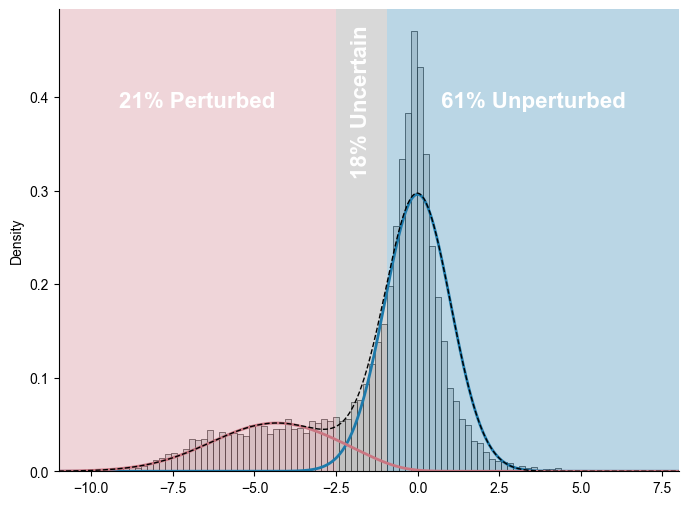

In [3]:
df = load_combined_pooled_Y2H_dataset(drop_superceded=False, 
                                      add_alphafold=False)

In [ ]:
experiments = df.loc[~df['experiment'].str.startswith('merge:'),
       'experiment'].unique()
# expect 22 experiments as of 2026-03-24
print(len(experiments), 'experiments')
df = df.loc[df['var_id'] != 'WT']
df['symbol'] = df['orf_id_wt'].map(orf_id_to_symbol)
if df['symbol'].isna().any():
    raise UserWarning("missing gene symbols for some ORF IDs")
df['interactor_symbol'] = df['interactor_id'].map(orf_id_to_symbol)
if df['interactor_symbol'].isna().any():
    raise UserWarning("missing gene symbols for some interactor ORF IDs")
df['ccsb_mutation_id'] = df['mutation_id']
df['ccsb_orf_id_reference'] = 'CCSBORF' + df['orf_id_wt'].astype(str)
df['ccsb_orf_id_interactor'] = 'CCSBORF' + df['interactor_id'].astype(str)
df['hgvs_protein'] = df['aa_change_hgvs']


columns_for_dacc_per_exp = [
    'spdi',
    'symbol',
    'ensembl_gene_id',
    'ccsb_mutation_id',
    'ccsb_orf_id_reference',
    'hgvs_protein',
    'nt_change',
    'ccsb_orf_id_interactor',
    'interactor_symbol',
    'log2FC_combined',
    'error_log2FC_combined',
]
columns_for_dacc_combined = columns_for_dacc_per_exp + ['perturbation_LLR', 
                                                        'perturbation_status']

for exp in experiments:
    (df.loc[df['experiment'] == exp, columns_for_dacc_per_exp]
       .to_csv(f"../data/internal/pooled-Y2H_log2FC_{exp}.tsv", 
               sep='\t',
               na_rep='NULL',
               index=False))
(df.loc[~df['is_replaced_by_merged_stat'],
       columns_for_dacc_combined]
    .to_csv("../data/internal/pooled-Y2H_combined-results.tsv", 
               sep='\t',
               na_rep='NULL',
               index=False)
)

22 experiments


In [6]:
df[columns_for_dacc_combined].isnull().sum()

spdi                        0
symbol                      0
ensembl_gene_id             0
ccsb_mutation_id            0
ccsb_orf_id_reference       0
hgvs_protein                0
nt_change                   0
ccsb_orf_id_interactor      0
interactor_symbol           0
log2FC_combined           872
error_log2FC_combined     872
perturbation_LLR          872
perturbation_status       872
dtype: int64